# **Klasifikasi Bahasa Isyarat | K - Nearest Neighbours**

Klasifikasi bahasa isyarat menggunakan algoritma K - Nearest Neighbours.

## 1. Data Understanding 

### 1.1 Import Library 

In [146]:
# Impor pustaka yang diperlukan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Import & Dataset Understanding 

In [147]:
# Import data train & test 
sibi_train = pd.read_csv('Datafull train.csv')
sibi_test = pd.read_csv('datatest.csv')

In [148]:
# Tmpilkan 5 baris teratas data train
print('\n5 baris teratas data train:')
sibi_train.head()


5 baris teratas data train:


,0x;0y;1x;1y;2x;2y;3x;3y;4x;4y;5x;5y;6x;6y;7x;7y;8x;8y;9x;9y;10x;10y;11x;11y;12x;12y;13x;13y;14x;14y;15x;15y;16x;16y;17x;17y;18x;18y;19x;19y;20x;20y;char
0,449.894;638.530;329.537;588.029;262.366;475.70...
1,459.426;638.641;347.614;599.550;273.522;486.96...
2,444.194;659.268;326.598;616.910;253.226;497.91...
3,443.780;650.429;324.970;607.825;252.818;487.20...
4,452.860;638.769;340.436;595.407;272.323;487.49...


In [149]:
# Pisah kolom data train 
sibi_train = pd.read_csv('Datafull train.csv', sep=';')
sibi_train.head()


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,449.894,638.530,329.537,588.029,262.366,475.709,253.967,343.421,247.663,236.477,...,475.346,591.398,426.475,592.339,341.419,548.671,413.658,541.039,454.239,NaN
1,459.426,638.641,347.614,599.550,273.522,486.969,262.374,354.810,248.102,248.011,...,471.021,587.605,425.540,598.047,337.165,559.660,410.858,548.164,455.238,A
2,444.194,659.268,326.598,616.910,253.226,497.914,243.082,361.876,239.491,259.676,...,476.613,560.803,418.030,567.584,346.090,533.656,416.844,524.283,450.811,A
3,443.780,650.429,324.970,607.825,252.818,487.201,244.345,356.561,243.655,256.638,...,473.187,573.173,418.568,580.205,339.026,541.187,411.295,528.062,445.777,A
4,452.860,638.769,340.436,595.407,272.323,487.497,254.365,357.569,231.482,241.993,...,463.566,577.341,425.073,581.486,337.553,551.375,410.228,546.574,449.936,A


In [150]:
# Tampilkan 5 baris teratas data test
print('\n5 baris teratas data test:')
sibi_test.head()


5 baris teratas data test:


,0x;0y;1x;1y;2x;2y;3x;3y;4x;4y;5x;5y;6x;6y;7x;7y;8x;8y;9x;9y;10x;10y;11x;11y;12x;12y;13x;13y;14x;14y;15x;15y;16x;16y;17x;17y;18x;18y;19x;19y;20x;20y;char
0,449.429;643.857;327.271;587.170;265.731;484.23...
1,451.351;653.700;333.252;594.944;265.111;486.31...
2,457.565;692.363;335.312;635.283;267.992;518.50...
3,454.034;534.794;333.222;489.421;258.394;399.01...
4,449.840;545.633;327.645;504.473;256.748;405.65...


In [151]:
# Pisah kolom data train 
sibi_test = pd.read_csv('datatest.csv', sep=';')
sibi_test.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
0,449.429,643.857,327.271,587.170,265.731,484.233,246.689,362.602,231.657,252.290,...,480.806,582.295,427.375,587.343,339.388,547.296,415.208,536.242,454.387,NaN
1,451.351,653.700,333.252,594.944,265.111,486.310,256.936,354.813,248.984,239.251,...,491.502,598.279,438.230,609.486,345.403,559.002,414.437,543.311,457.700,A
2,457.565,692.363,335.312,635.283,267.992,518.501,261.948,388.552,264.993,288.713,...,490.838,584.324,453.037,589.529,370.452,548.982,435.461,536.997,465.605,A
3,454.034,534.794,333.222,489.421,258.394,399.013,232.771,269.755,218.668,160.658,...,358.808,537.166,308.455,531.600,212.394,505.065,284.374,499.484,329.256,A
4,449.840,545.633,327.645,504.473,256.748,405.653,228.244,273.756,210.097,166.311,...,365.462,545.115,312.461,548.587,221.122,514.636,287.484,503.828,326.010,A


In [152]:
# Tampilkan informasi data train
print('\nInformasi data train:')
sibi_train.info()


Informasi data train:
<class 'pandas.DataFrame'>
RangeIndex: 32849 entries, 0 to 32848
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0x      32849 non-null  float64
 1   0y      32849 non-null  float64
 2   1x      32849 non-null  float64
 3   1y      32849 non-null  float64
 4   2x      32849 non-null  float64
 5   2y      32849 non-null  float64
 6   3x      32849 non-null  float64
 7   3y      32849 non-null  float64
 8   4x      32849 non-null  float64
 9   4y      32849 non-null  float64
 10  5x      32849 non-null  float64
 11  5y      32849 non-null  float64
 12  6x      32849 non-null  float64
 13  6y      32849 non-null  float64
 14  7x      32849 non-null  float64
 15  7y      32849 non-null  float64
 16  8x      32849 non-null  float64
 17  8y      32849 non-null  float64
 18  9x      32849 non-null  float64
 19  9y      32849 non-null  float64
 20  10x     32849 non-null  float64
 21  10y     32849 non-null 

In [153]:
# Tampilkan informasi data test
print('\nInformasi data test')
sibi_test.info()


Informasi data test
<class 'pandas.DataFrame'>
RangeIndex: 8213 entries, 0 to 8212
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0x      8213 non-null   float64
 1   0y      8213 non-null   float64
 2   1x      8213 non-null   float64
 3   1y      8213 non-null   float64
 4   2x      8213 non-null   float64
 5   2y      8213 non-null   float64
 6   3x      8213 non-null   float64
 7   3y      8213 non-null   float64
 8   4x      8213 non-null   float64
 9   4y      8213 non-null   float64
 10  5x      8213 non-null   float64
 11  5y      8213 non-null   float64
 12  6x      8213 non-null   float64
 13  6y      8213 non-null   float64
 14  7x      8213 non-null   float64
 15  7y      8213 non-null   float64
 16  8x      8213 non-null   float64
 17  8y      8213 non-null   float64
 18  9x      8213 non-null   float64
 19  9y      8213 non-null   float64
 20  10x     8213 non-null   float64
 21  10y     8213 non-null   flo

In [154]:
# Tampilkan dimensi dataset
print('\nDimensi data train:')
print('Jumlah baris:', sibi_train.shape[0])
print('Jumlah kolom:', sibi_train.shape[1])

print('\nDimensi data test:')
print('Jumlah baris:', sibi_test.shape[0])
print('Jumlah kolom:', sibi_test.shape[1])


Dimensi data train:
Jumlah baris: 32849
Jumlah kolom: 43

Dimensi data test:
Jumlah baris: 8213
Jumlah kolom: 43


In [155]:
# Ambil sample 10% dari total data train 
sibi = sibi_train.groupby('char', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))

print('\nDimensi data train setelah diambil sampel:')
print('Jumlah baris:', sibi.shape[0])
print('Jumlah kolom:', sibi.shape[1])


Dimensi data train setelah diambil sampel:
Jumlah baris: 3283
Jumlah kolom: 42


In [156]:
sibi.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16x,16y,17x,17y,18x,18y,19x,19y,20x,20y
1028,464.530,453.149,410.669,380.667,403.724,283.813,432.110,189.088,451.753,106.248,...,528.160,354.814,600.751,361.646,641.236,309.935,601.943,337.724,583.792,361.384
368,437.530,466.701,372.401,425.682,333.999,373.071,322.827,312.913,322.848,261.393,...,457.001,380.057,514.758,360.718,512.502,306.447,489.769,343.545,489.146,366.170
550,440.916,455.722,407.954,381.635,420.406,305.575,446.657,241.038,456.185,183.758,...,476.616,387.420,560.011,400.332,587.656,367.523,547.735,375.884,521.679,387.713
283,456.665,471.524,393.749,430.490,370.009,370.682,362.451,303.936,360.115,252.860,...,473.930,391.638,522.869,369.780,524.829,331.082,508.788,365.535,508.151,384.290
679,470.986,470.530,386.005,437.175,333.821,369.394,307.130,298.090,278.775,252.963,...,437.880,286.195,507.711,328.714,519.402,260.946,502.775,266.959,489.401,283.085


In [157]:
# Tampilkan total nilai unik data train
print('\nTotal nilai unik per fitur:')
sibi.nunique()


Total nilai unik per fitur:


0x     3192
0y     3232
1x     3226
1y     3246
2x     3261
2y     3245
3x     3267
3y     3257
4x     3270
4y     3260
5x     3253
5y     3254
6x     3269
6y     3265
7x     3271
7y     3257
8x     3270
8y     3264
9x     3257
9y     3248
10x    3265
10y    3255
11x    3257
11y    3254
12x    3264
12y    3270
13x    3250
13y    3251
14x    3257
14y    3255
15x    3263
15y    3260
16x    3264
16y    3269
17x    3243
17y    3250
18x    3261
18y    3264
19x    3262
19y    3268
20x    3266
20y    3268
dtype: int64

In [158]:
# Tampilkan total missing value
print('\nTotal missing value:', sibi.isnull().sum().sum())


Total missing value: 2


In [159]:
# Tampilkan baris dengan missing value
print('\nBaris dengan missing value:')
sibi[sibi.isnull().any(axis=1)]


Baris dengan missing value:


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16x,16y,17x,17y,18x,18y,19x,19y,20x,20y
5555,445.98,478.090,378.346,436.979,340.765,386.527,333.324,331.266,337.771,301.468,...,460.432,335.468,500.910,347.789,510.254,289.516,502.880,292.999,501.242,303.602
14648,449.77,459.116,356.855,414.605,317.431,354.582,309.624,282.151,306.913,233.760,...,412.263,361.334,501.792,319.937,494.994,257.280,466.001,295.054,460.115,329.626


In [160]:
# Tampilkan total data duplikat 
print('\nTotal data duplikat:', sibi.duplicated().sum())


Total data duplikat: 1


In [161]:
# Tampilkan baris duplikat 
print('\nBaris duplikat:')
sibi[sibi.duplicated(keep=False)]


Baris duplikat:


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16x,16y,17x,17y,18x,18y,19x,19y,20x,20y
19395,456.072,455.709,469.294,485.024,501.082,508.965,536.722,535.553,568.748,559.009,...,591.561,619.265,545.839,526.871,563.574,573.888,567.394,595.932,569.647,608.639
19394,456.072,455.709,469.294,485.024,501.082,508.965,536.722,535.553,568.748,559.009,...,591.561,619.265,545.839,526.871,563.574,573.888,567.394,595.932,569.647,608.639


In [162]:
# Pisah fitur numerik dan kategorikal
num_cols = sibi_train.select_dtypes(include=['int64', 'float64'])
cat_cols = sibi_train.select_dtypes(include=['category', 'object'])

/tmp/ipykernel_49293/4003604695.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = sibi_train.select_dtypes(include=['category', 'object'])


## 2. Exploratory Data Analysis (EDA)

### 2.1 Multivariate Analysis

In [163]:
# Tampilkan statistik dataset
print('\nStatistik fitur numerik:')
sibi_train.describe()


Statistik fitur numerik:


,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16x,16y,17x,17y,18x,18y,19x,19y,20x,20y
count,32849.000000,32849.000000,32849.000000,32849.000000,32849.00000,32849.000000,32849.000000,32849.000000,32849.000000,32849.000000,...,32847.000000,32846.000000,32844.000000,32848.000000,32849.000000,32848.000000,32849.000000,32849.000000,32849.000000,32849.000000
mean,452.487562,475.714510,427.711225,445.098657,423.43866,400.280874,438.871542,362.268773,452.668220,338.853849,...,498.978343,364.348394,521.897306,387.946387,535.892408,354.024572,525.676819,358.802615,517.353640,365.814100
std,33.520120,52.909844,54.618299,52.776351,80.52885,69.214755,101.527047,93.655925,120.968362,114.740541,...,102.025223,118.615725,66.132425,73.711071,87.463863,96.457858,93.328696,103.021041,97.024746,110.399991
min,26.970000,0.000000,0.000000,0.000000,-30.64200,0.000000,-67.560000,0.000000,-95.991000,0.000000,...,-139.906000,7.845000,-49.063000,54.555000,-83.522000,35.426000,-92.401000,39.292000,-98.609000,45.460000
25%,441.028000,453.376000,391.581000,410.966000,365.05200,352.689000,367.965000,300.572000,374.013000,264.204000,...,452.645000,304.218000,493.478000,340.677750,494.840000,290.776000,483.768000,291.999000,475.193000,296.790000
50%,450.211000,468.697000,413.540000,436.465000,407.72500,383.968000,430.541000,337.837000,452.060000,310.332000,...,489.608000,365.309500,529.412000,371.636500,545.175000,329.886000,531.410000,341.738000,517.521000,359.703000
75%,461.090000,491.656000,463.077000,471.833000,479.73100,433.306000,506.223000,396.942000,530.462000,375.741000,...,543.359000,409.731500,559.936250,423.889000,589.752000,392.063000,577.235000,400.458000,567.809000,414.288000
max,846.956000,964.173000,822.414000,861.044000,835.39700,828.416000,854.552000,837.067000,898.948000,840.879000,...,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000,997.123000


Fitur - fitur nuberik cenderung memiliki selisih nilai max dan 75% yang cukup besar. Dimana, ini besar kemungkinan adanya nilai diluar range.

In [164]:
# Tampilkan statistik fitur kategorikal 
print('\nStatistik fitur Kategorikal:')
sibi_train['char'].describe()


Statistik fitur Kategorikal:


count     32825
unique       24
top           P
freq       1677
Name: char, dtype: object

Huruf yang paling sering muncul adalah huruf 'P', dengan nilai kemunculan 1677 kali.

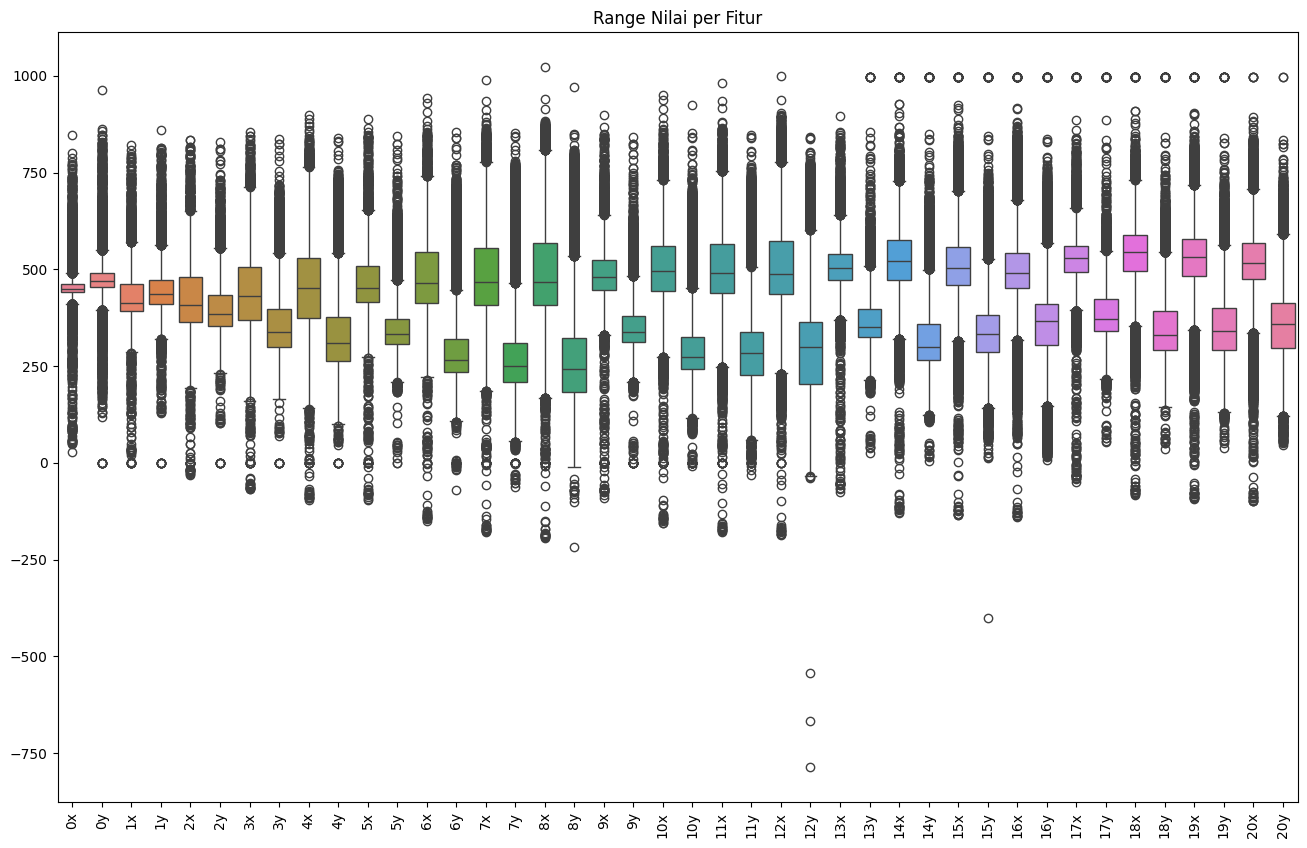

In [165]:
# Tampilkan range perfitur
plt.figure(figsize=(16, 10))
sns.boxplot(sibi_train)
plt.xticks(rotation=90)
plt.title('Range Nilai per Fitur')
plt.show()

Banyak sekali nilai diluar range. Menurut kami, itu ada variasi dari nilai per fitur.

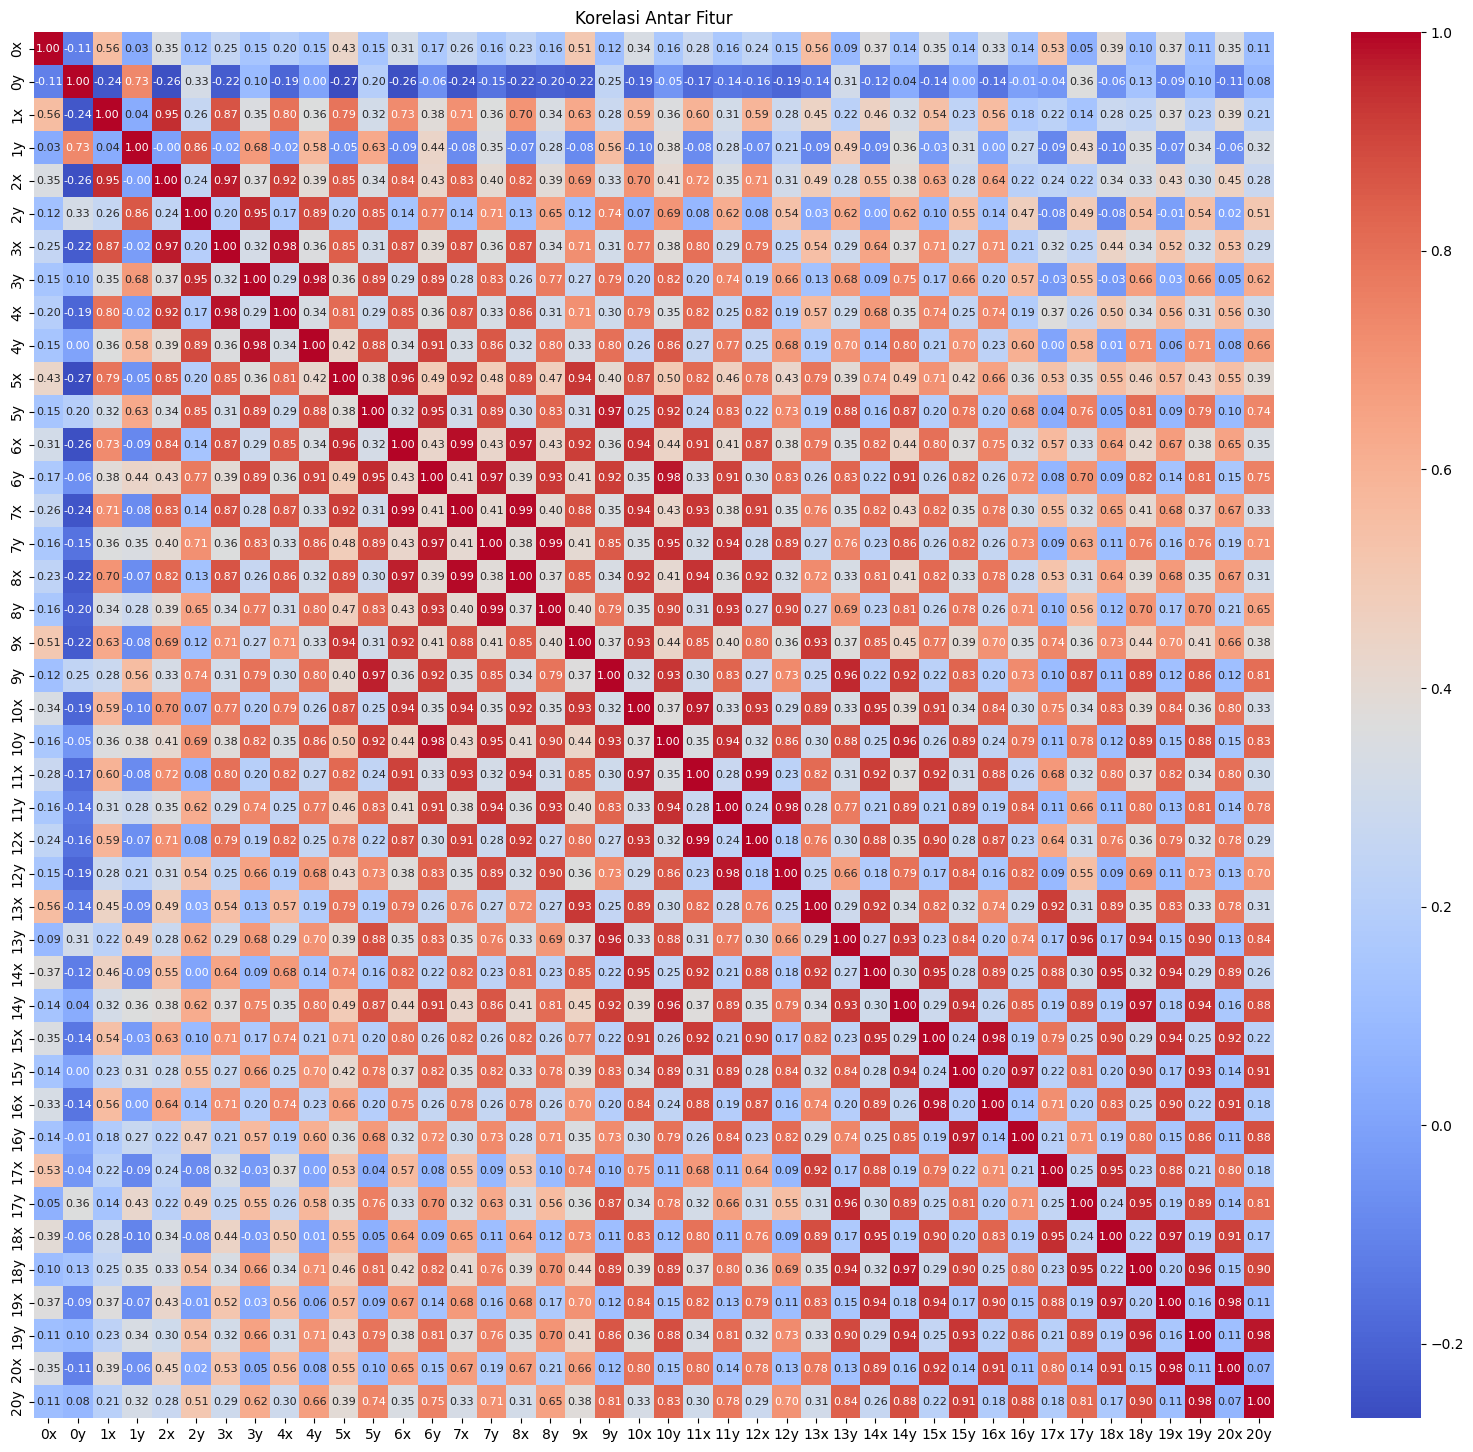

In [166]:
# Tampilkan korelasi antar fitur 
correlation = num_cols.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            annot_kws={"size": 8})
plt.title('Korelasi Antar Fitur')
plt.show()

### 2.2 Univariate Analysis

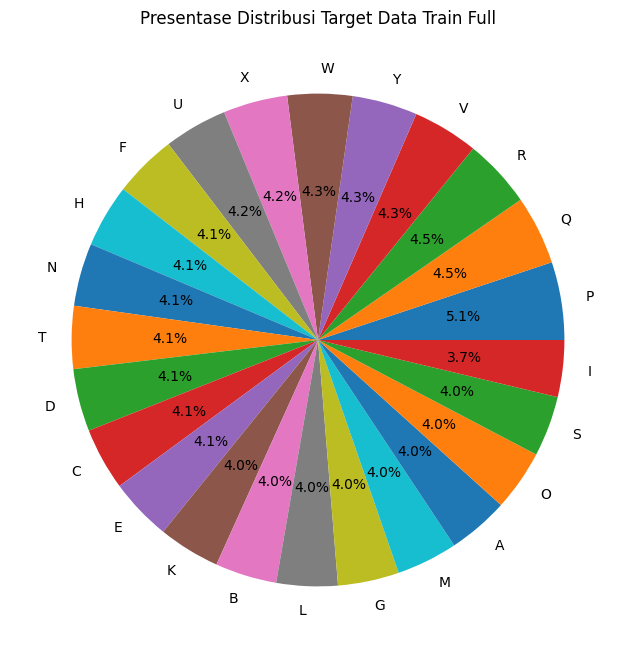

In [167]:
# Visualisasi presentase distribusi target
counts = sibi_train['char'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%')
plt.title('Presentase Distribusi Target Data Train Full')
plt.show()

In [168]:
# # Visualisasi presentase distribusi target
# counts = sibi['char'].value_counts()

# plt.figure(figsize=(8,8))
# plt.pie(counts,
#         labels=counts.index,
#         autopct='%1.1f%%')
# plt.title('Presentase Distribusi Target Data Train Sample')
# plt.show()

In [169]:
# Tampilkan nilai unik target
print('\nNilai unik target:\n', sibi_train['char'].unique())


Nilai unik target:
 <StringArray>
[nan, 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O',
 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Length: 25, dtype: str


Tidak ada huruf 'J' dan 'Z'.

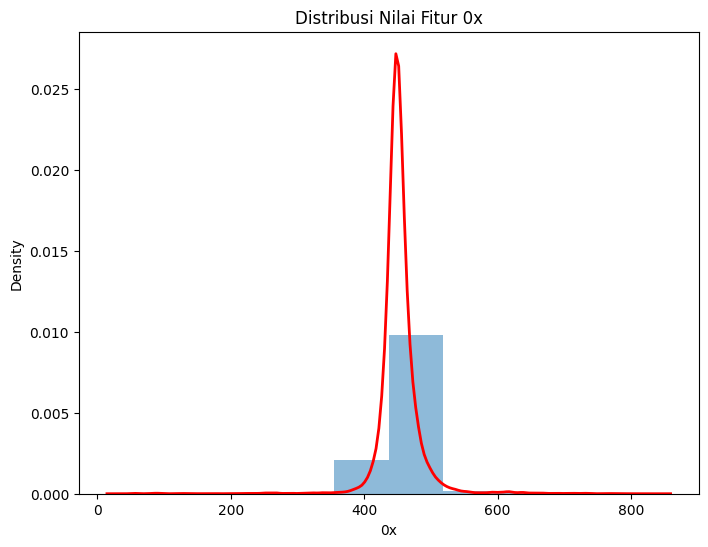

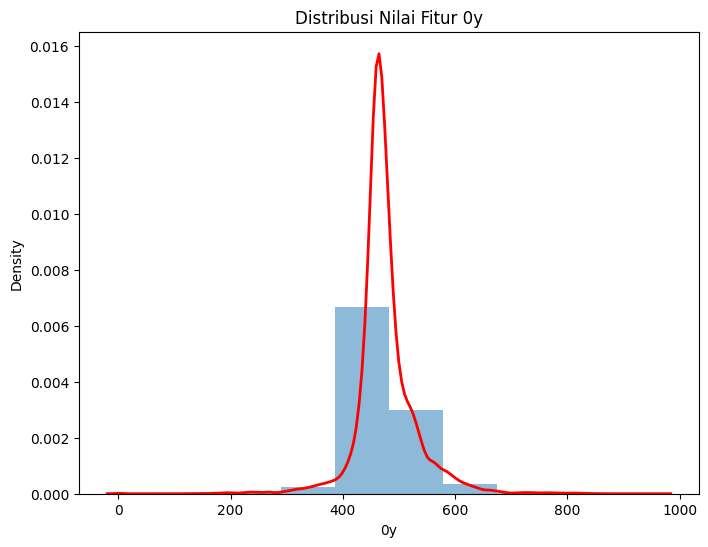

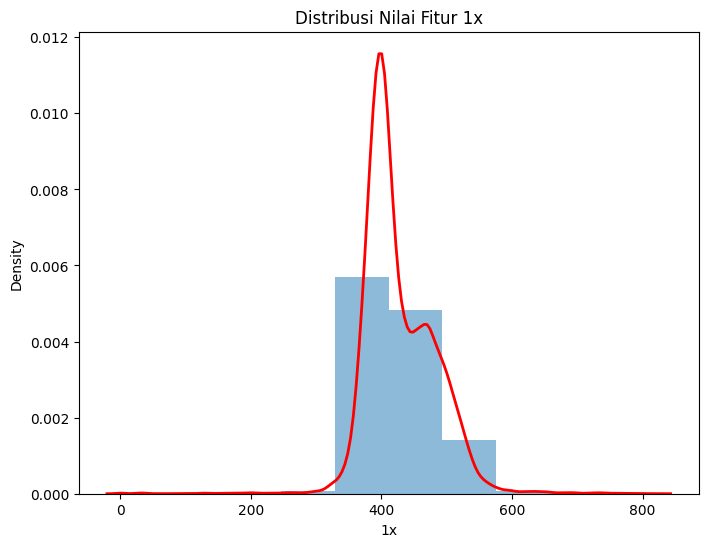

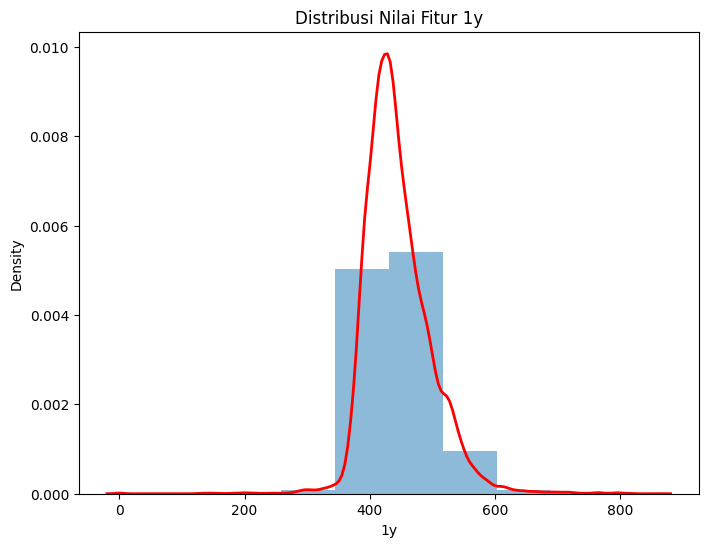

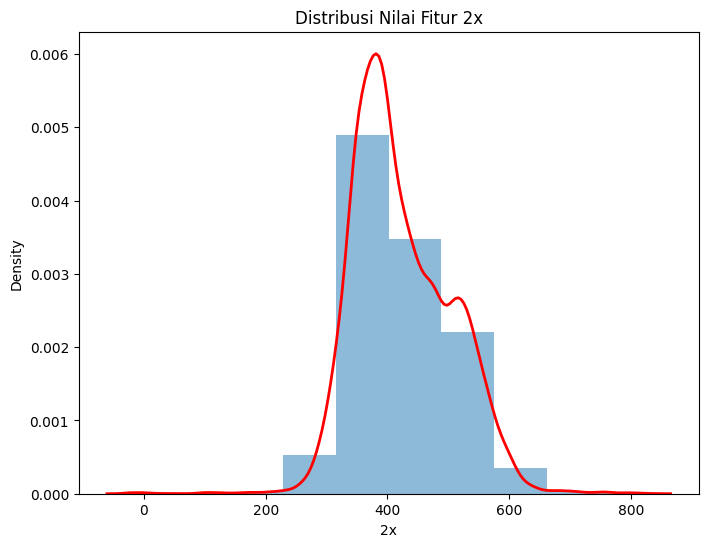

In [170]:
# Visualisasi distribusi nilai fitur numerik (sampel 5 fitur saja untuk efisiensi)
for i, col in enumerate(num_cols.columns[:5]):  # Hanya 5 fitur pertama
    plt.figure(figsize=(8, 6))
    plt.hist(data=num_cols, x=col, alpha=0.5, density=True)
    sns.kdeplot(num_cols[col], color='red', linewidth=2)
    plt.title(f'Distribusi Nilai Fitur {col}')
    plt.show()

Semua penyebaran nilai pada fitur merata. 

### 2.3 Bivariate Analysis

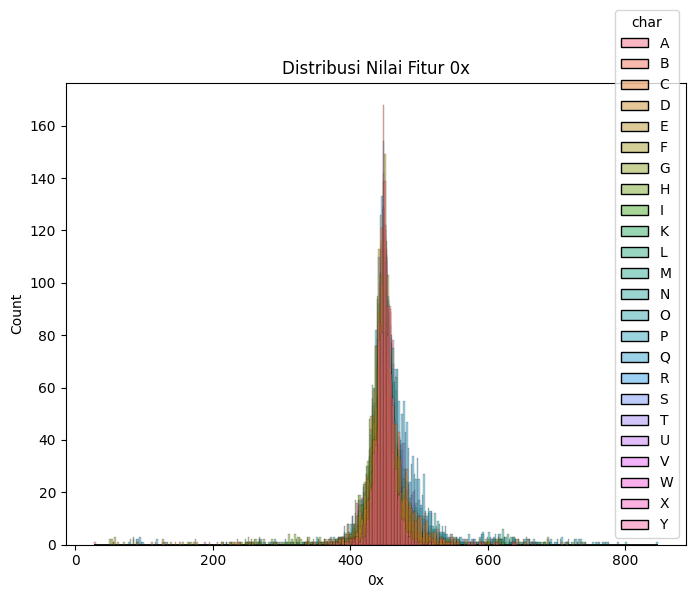

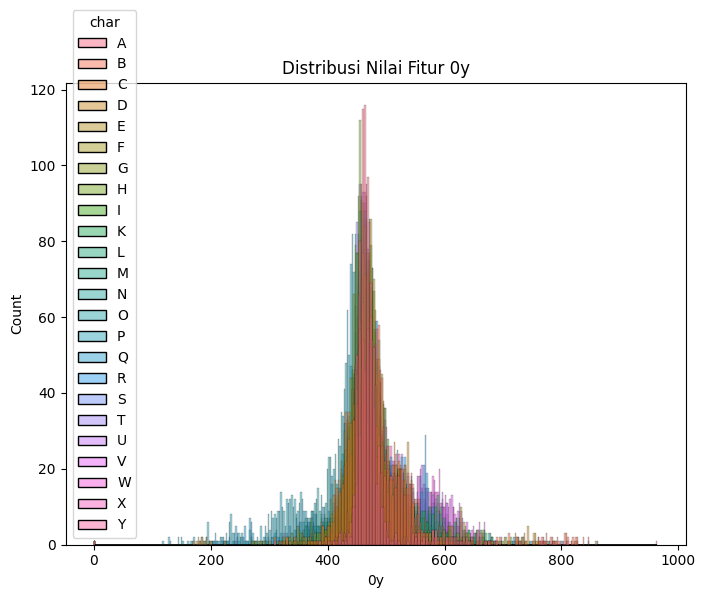

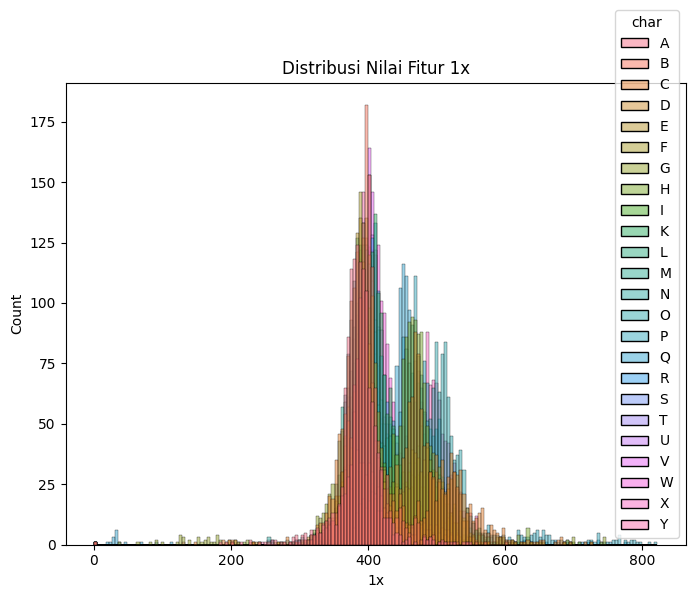

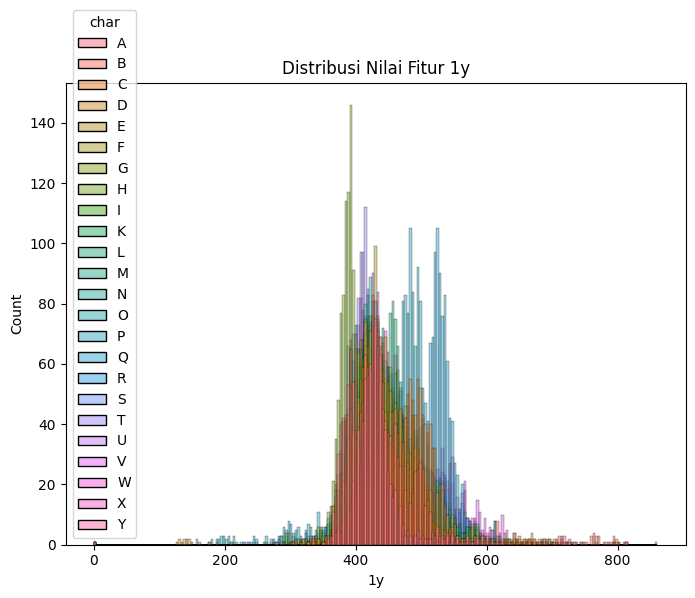

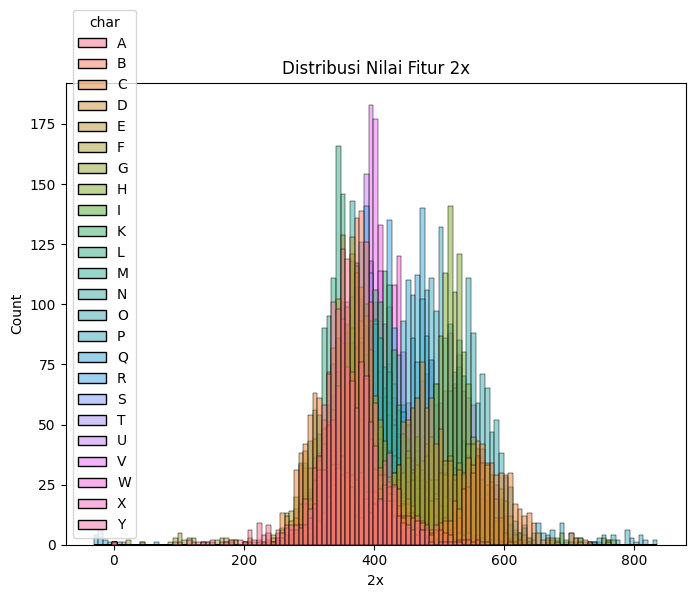

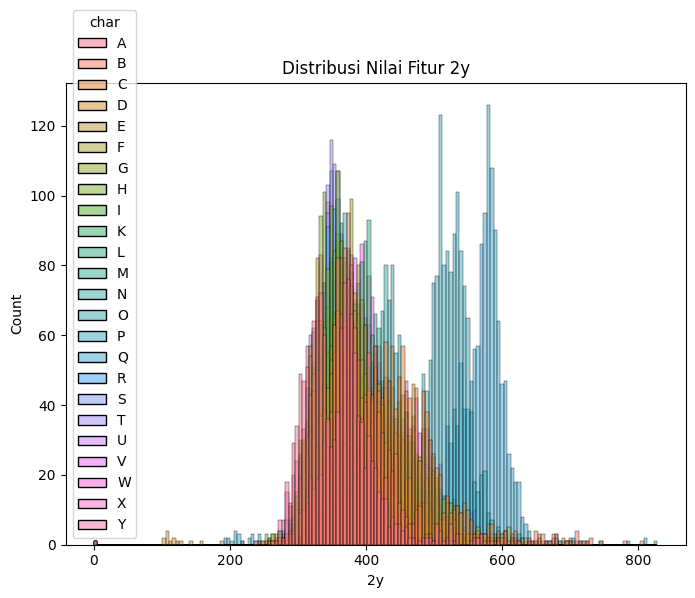

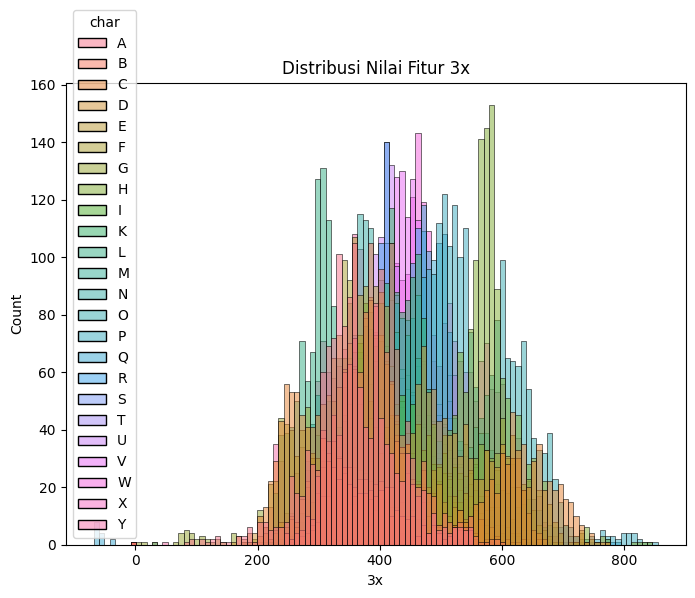

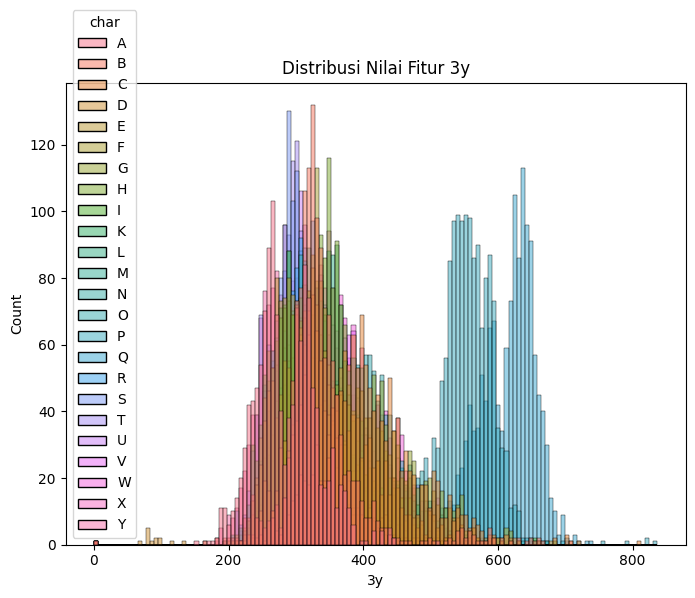

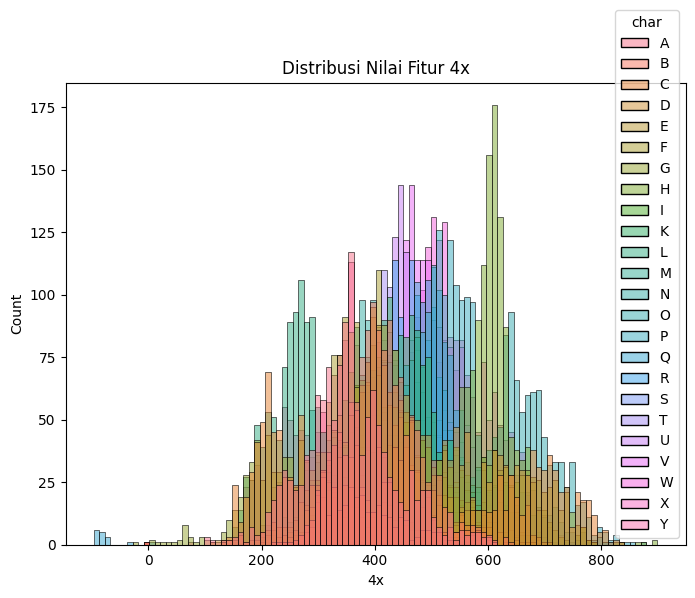

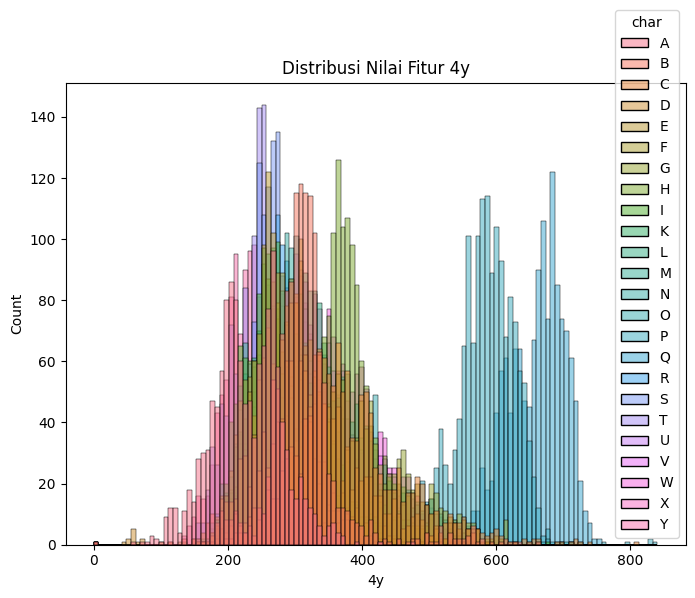

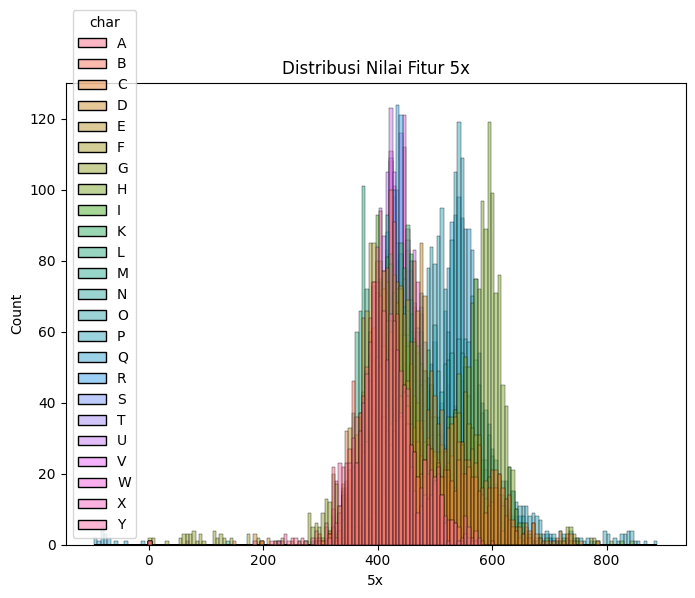

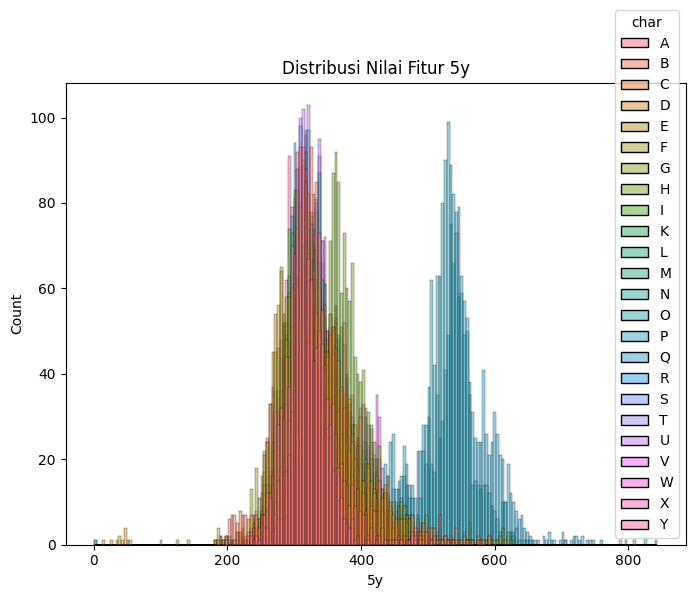

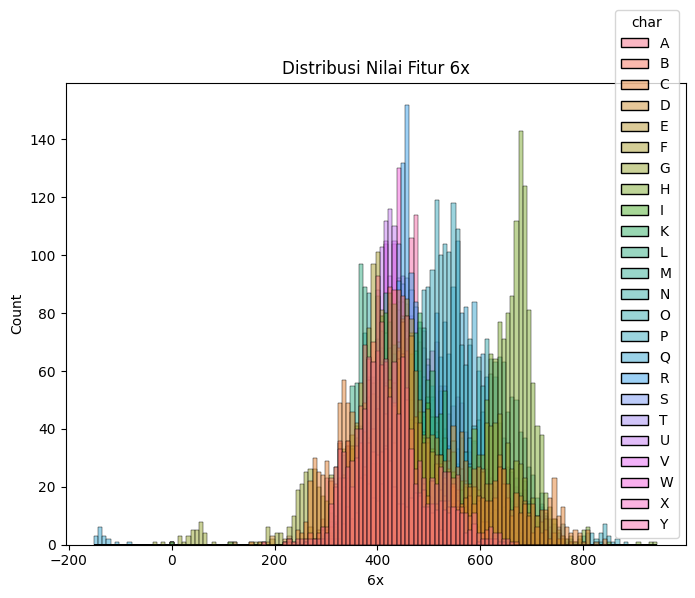

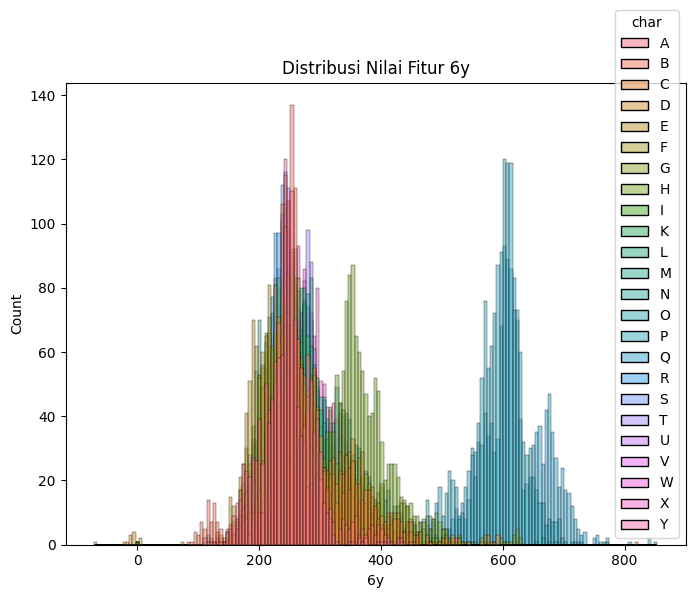

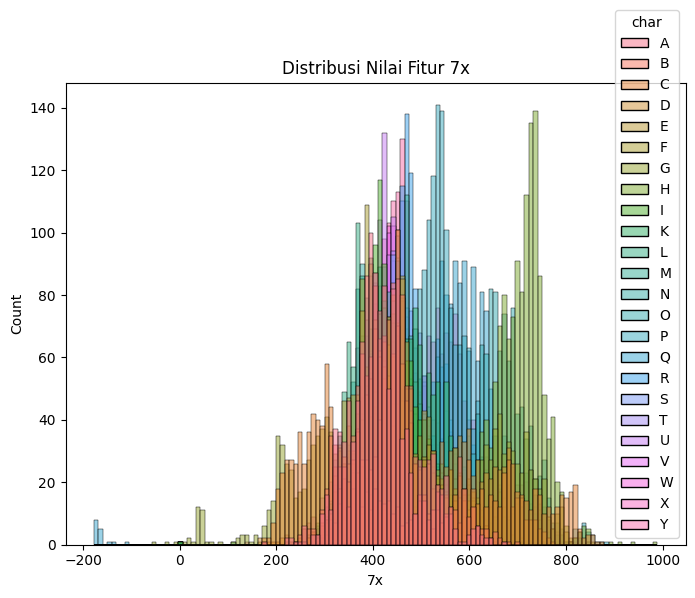

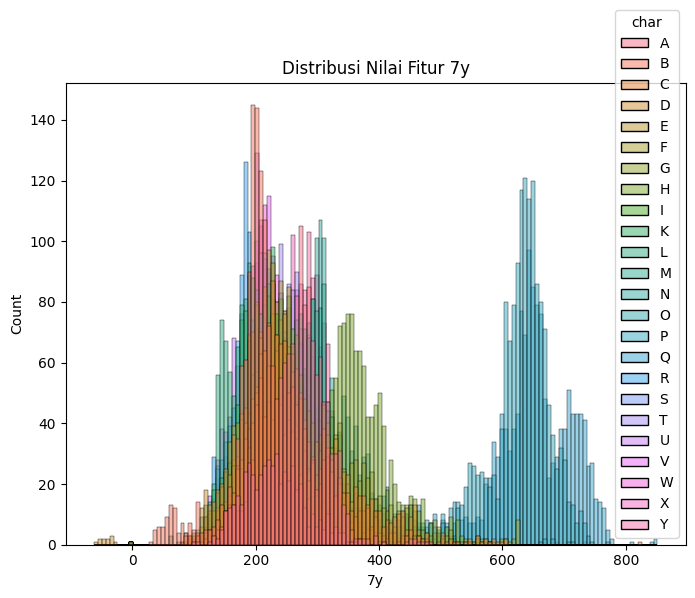

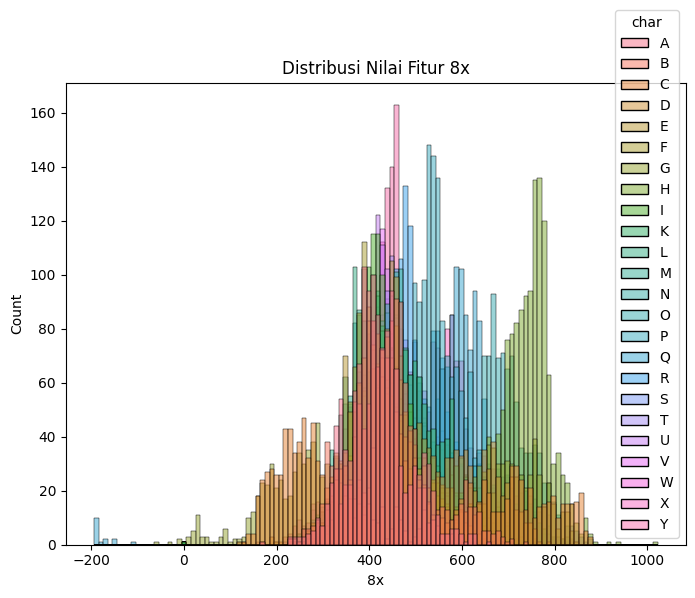

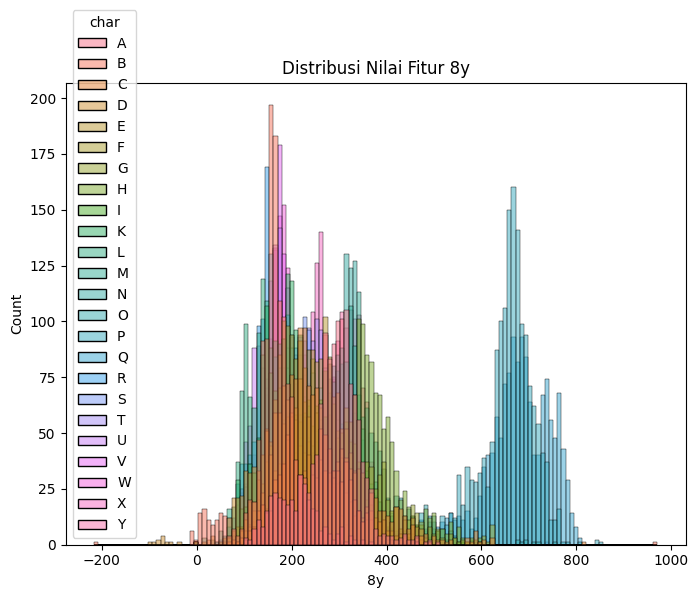

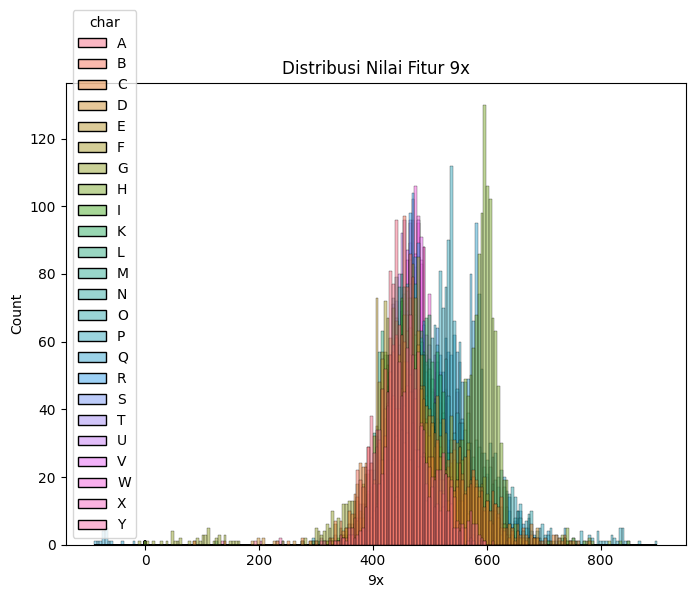

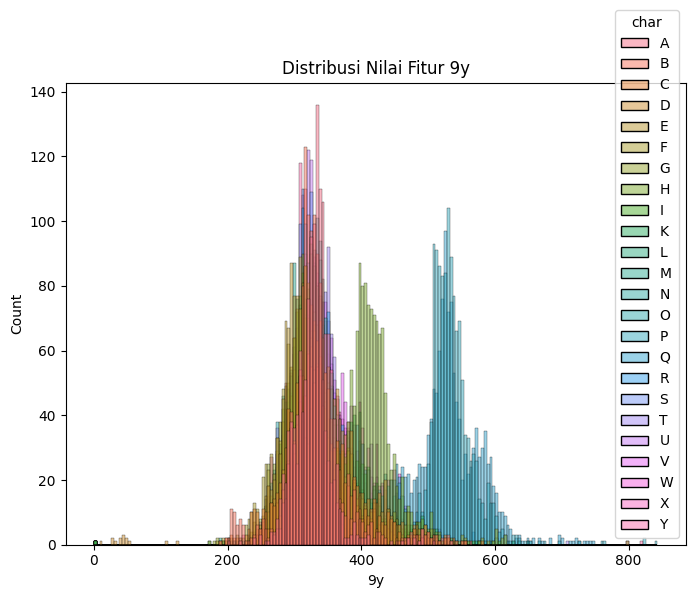

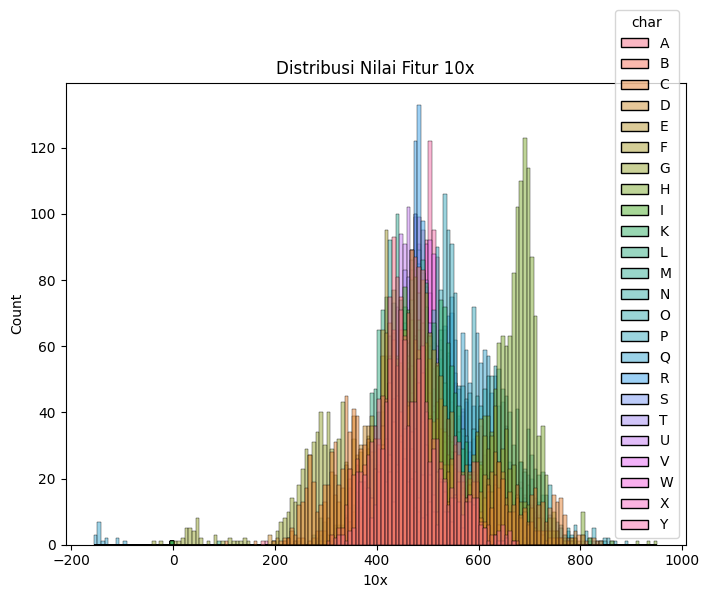

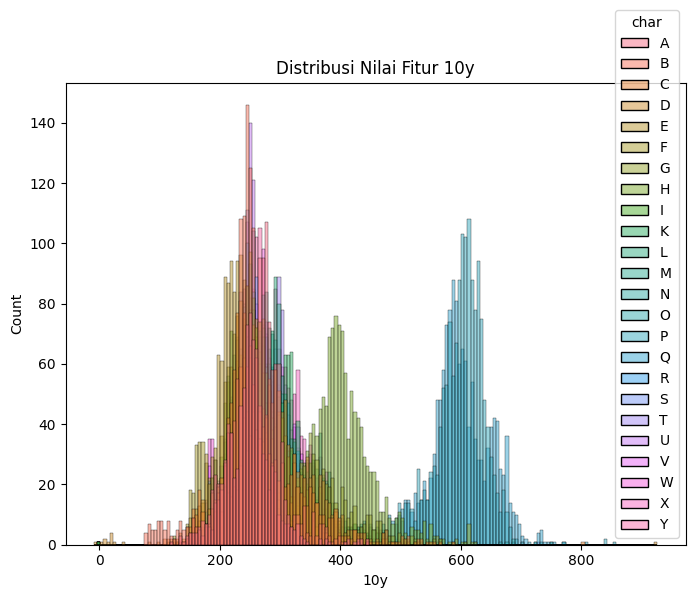

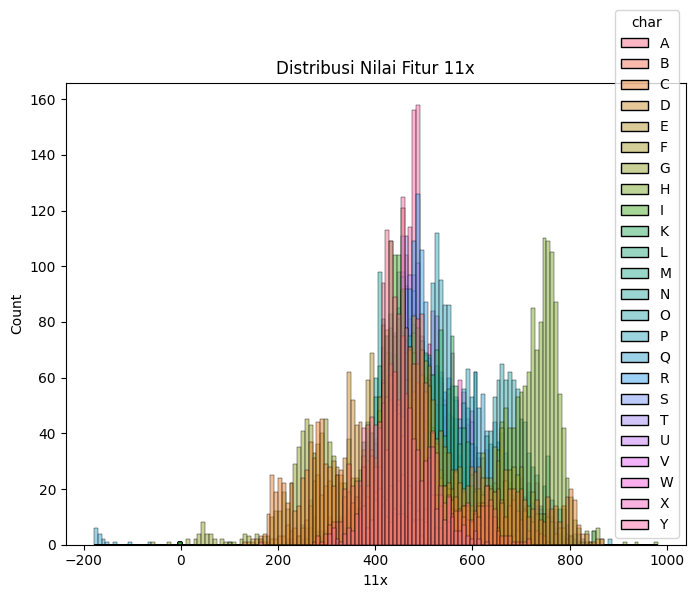

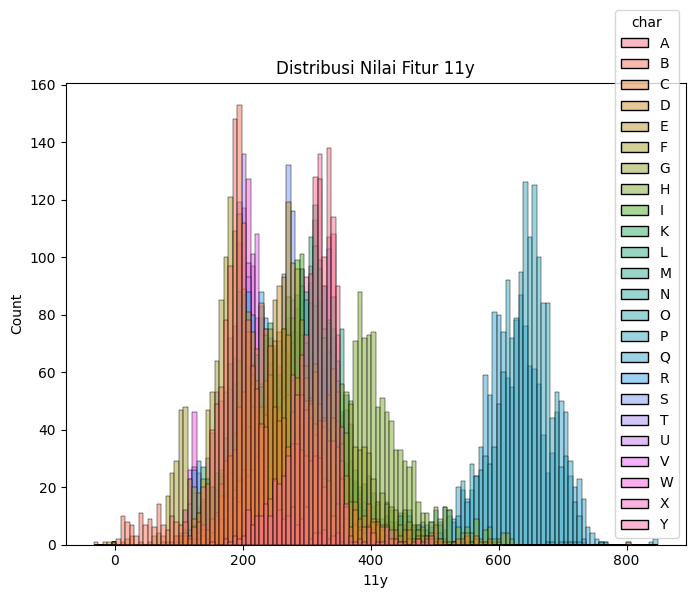

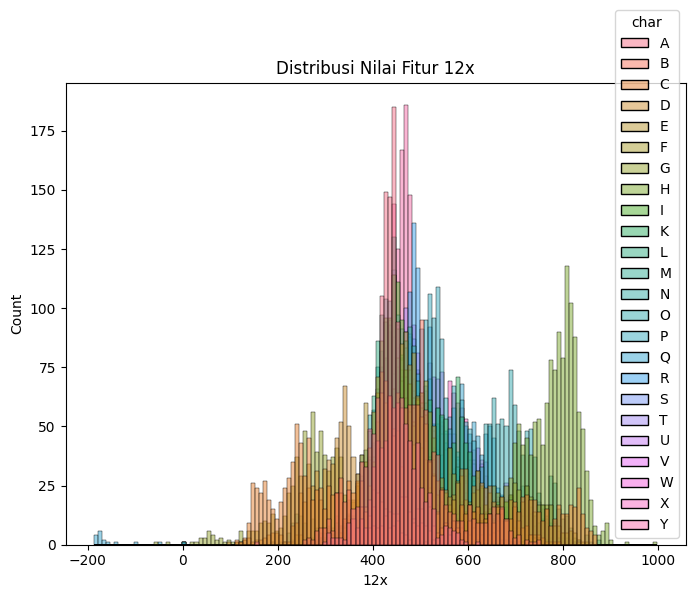

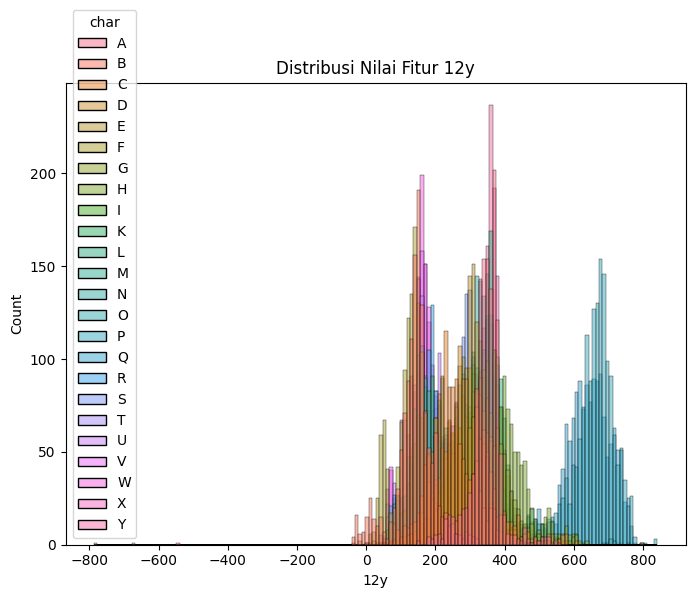

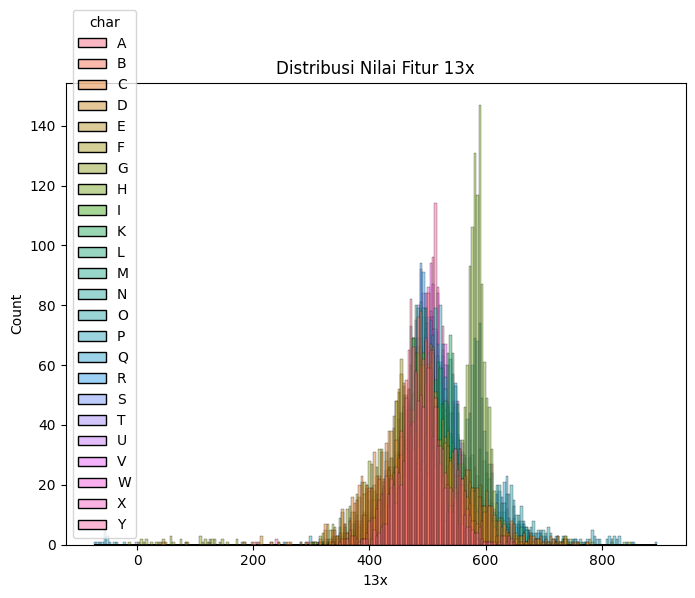

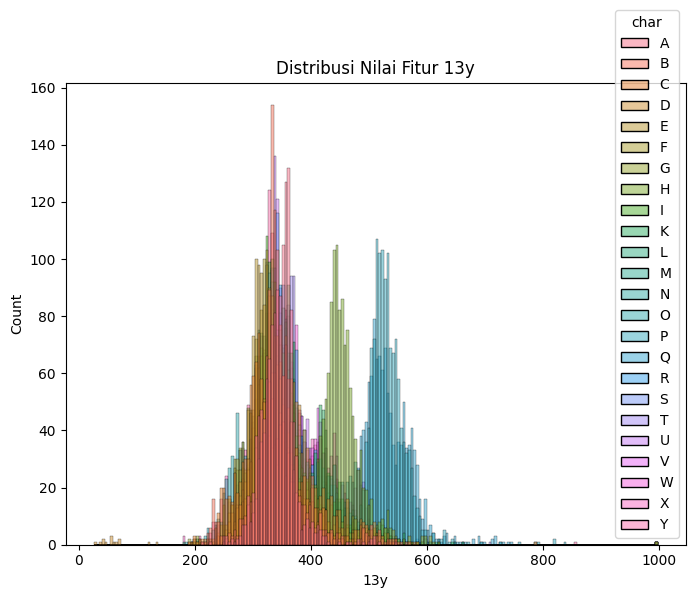

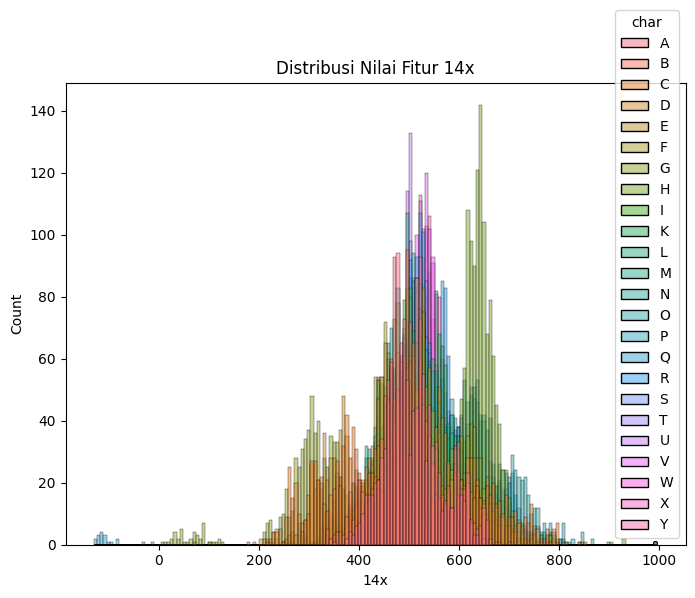

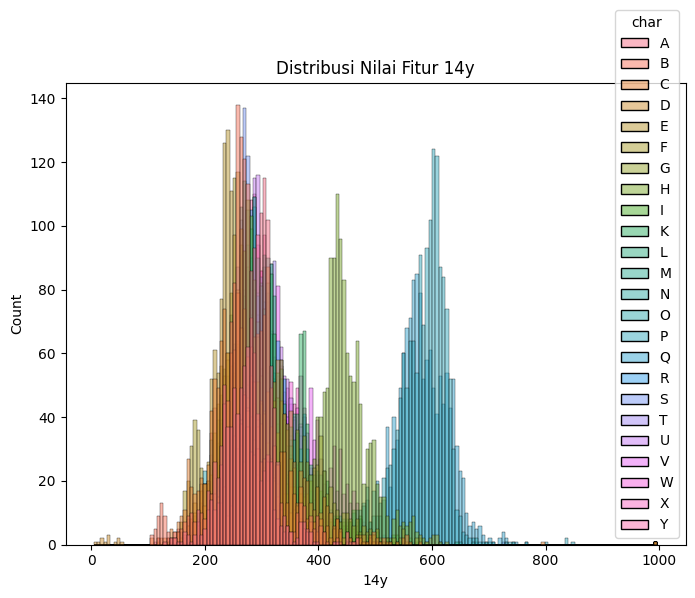

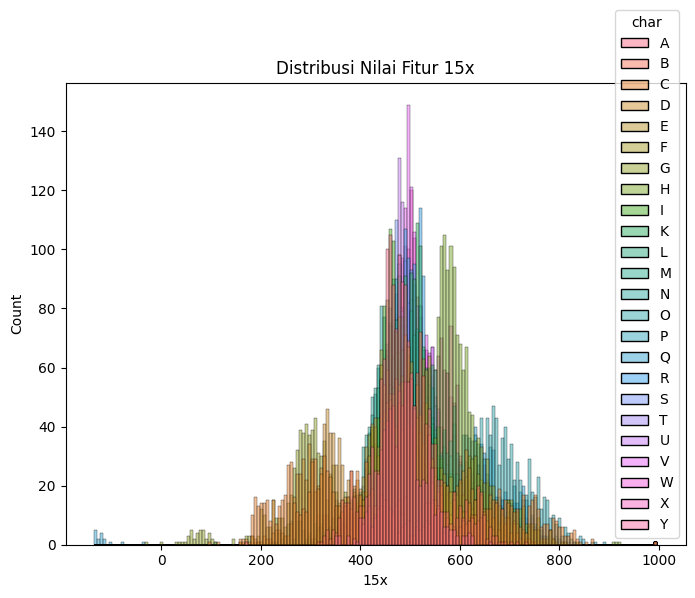

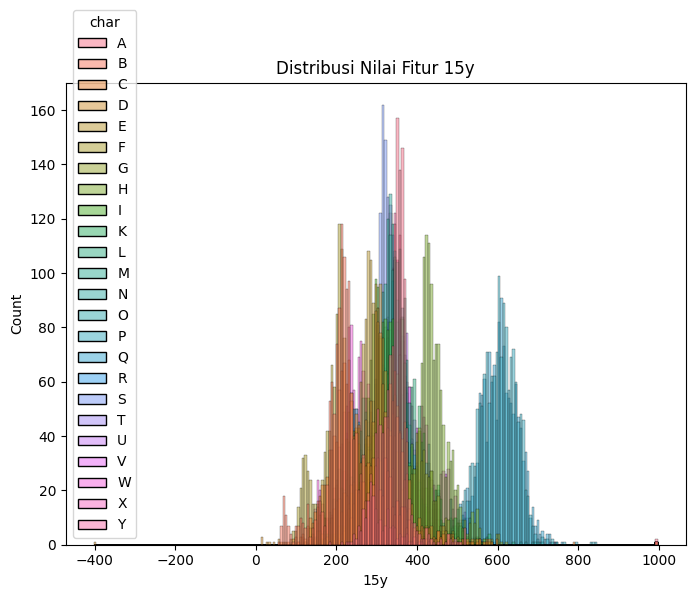

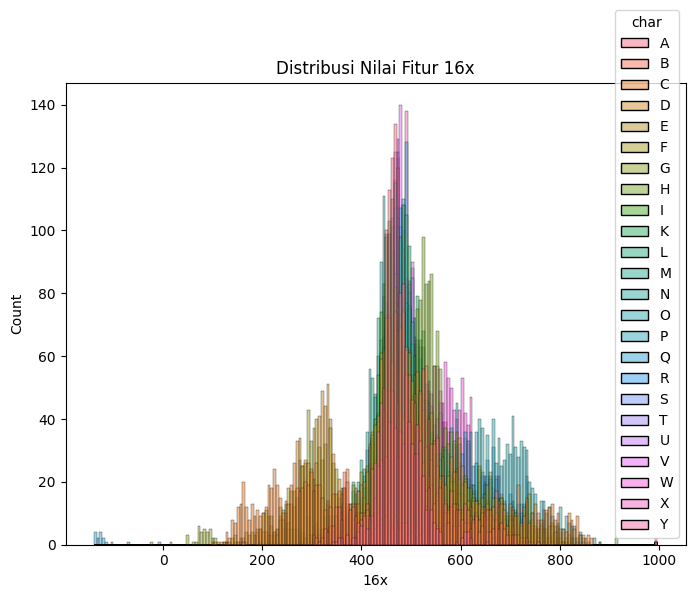

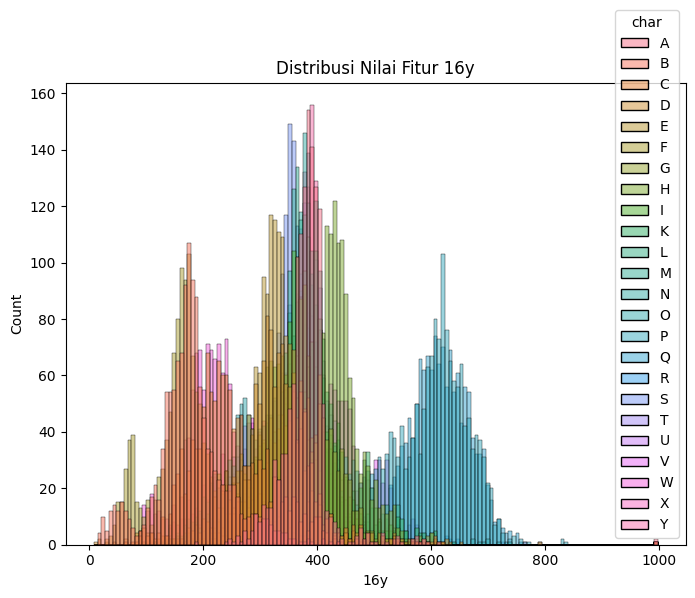

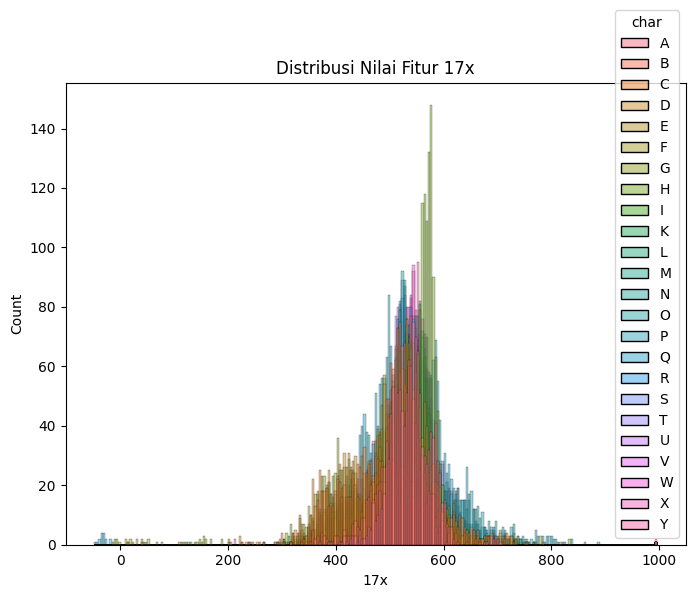

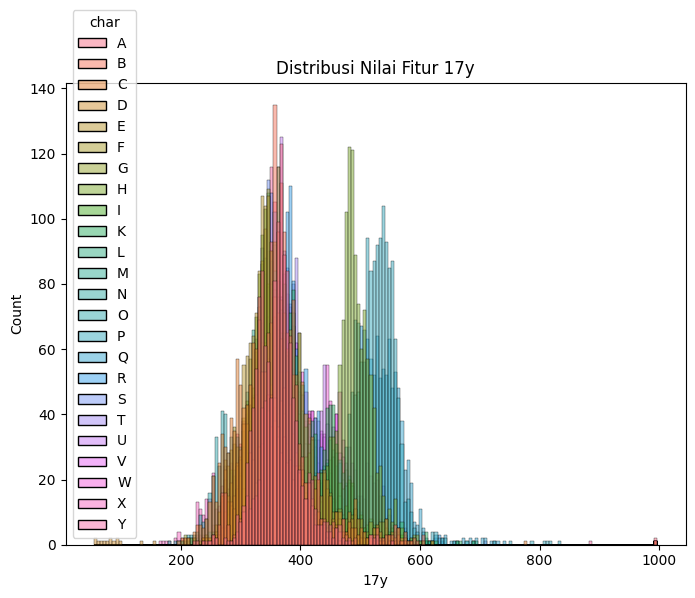

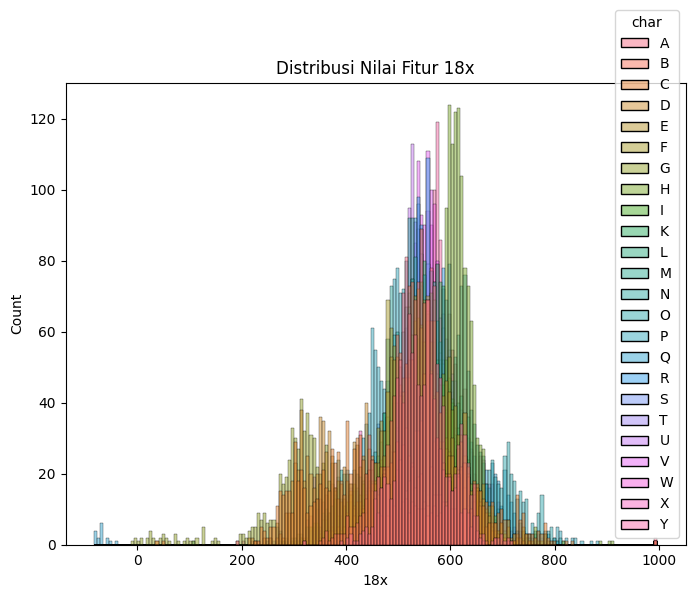

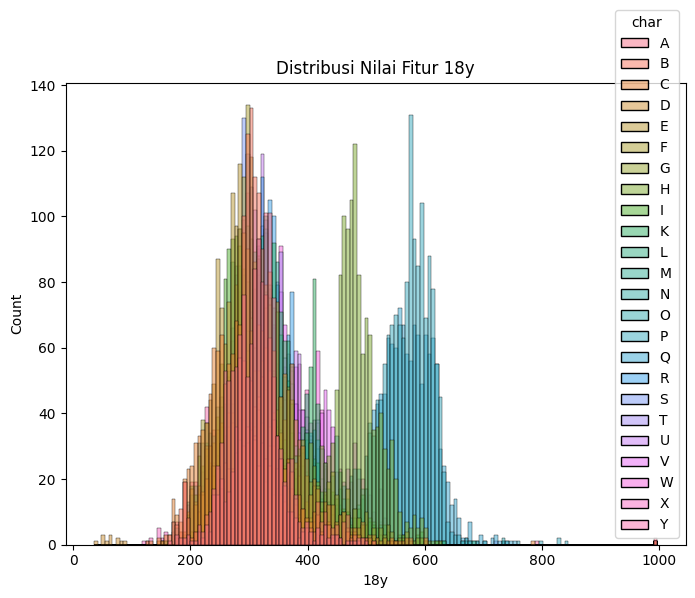

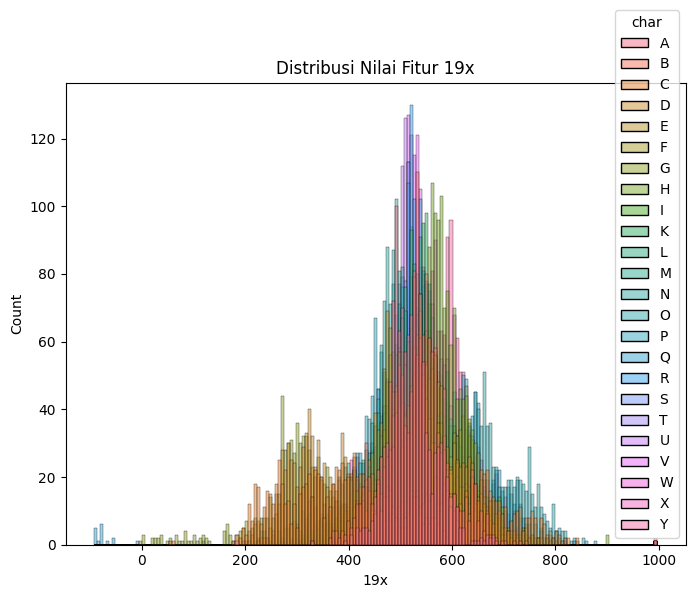

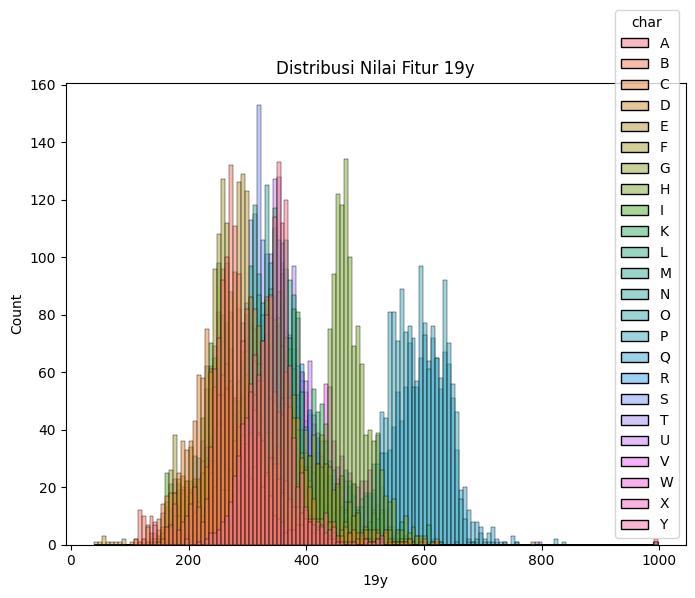

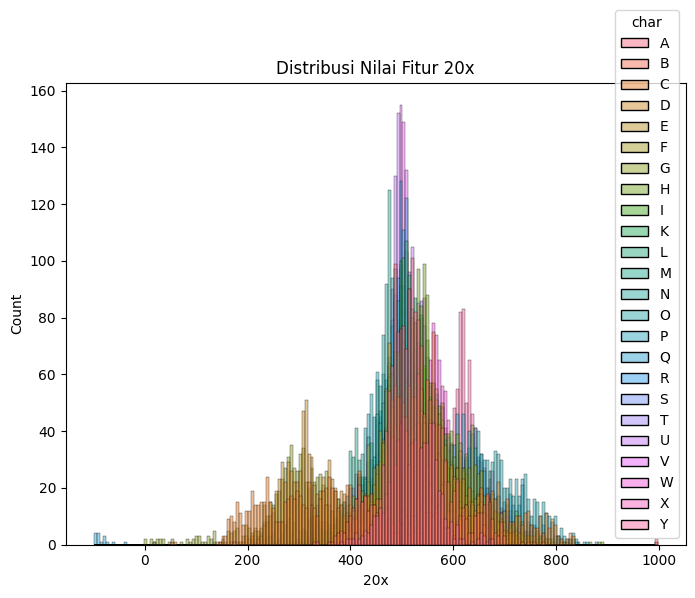

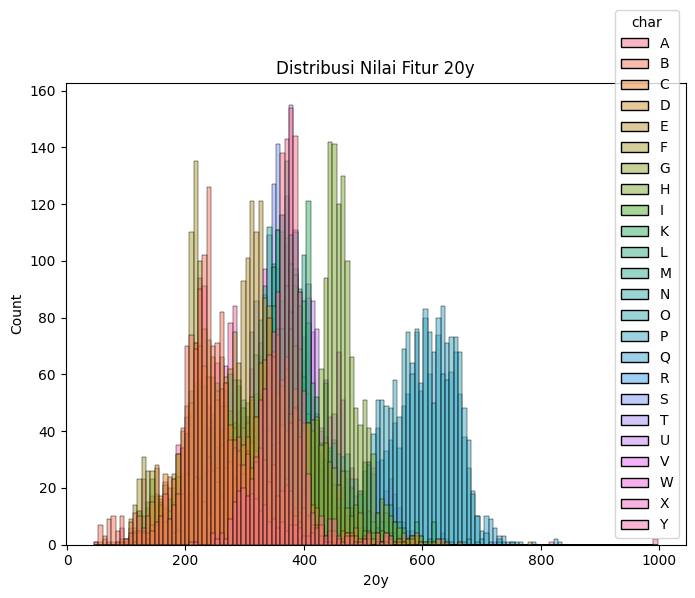

In [171]:
# Visualisasi fitur numerik vs target
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=num_cols, x=col, hue=sibi_train['char'])
    plt.title(f'Distribusi Nilai Fitur {col}')
    plt.show()


Penyebaran nilai terhadap target cenderung tidak ada pemisahan yang jelas dan bertumpuk. Sehingga, kurang informatif.

## 3. Data Preprocessing

### 3.1 Handling Missing Value

In [172]:
# Tampilkan baris dengan missing value
sibi[sibi.isnull().any(axis=1)]

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16x,16y,17x,17y,18x,18y,19x,19y,20x,20y
5555,445.98,478.090,378.346,436.979,340.765,386.527,333.324,331.266,337.771,301.468,...,460.432,335.468,500.910,347.789,510.254,289.516,502.880,292.999,501.242,303.602
14648,449.77,459.116,356.855,414.605,317.431,354.582,309.624,282.151,306.913,233.760,...,412.263,361.334,501.792,319.937,494.994,257.280,466.001,295.054,460.115,329.626


In [173]:
# Tangani nissing value dengan median
median = sibi['15y'].median()
sibi['15y'] = sibi['15y'].fillna(median)

# Tampilkan total missing value 
print('\nTotal missing value setelah ditangani:', sibi.isnull().sum().sum())


Total missing value setelah ditangani: 0


### 3.2 Handling Duplicate Value 


In [174]:
# Hapus data duplikat baris pertama
sibi = sibi.drop_duplicates(keep='first')

# Tampilkan total data duplikat setelah ditangani
print('\nTotal data duplikat setelah ditangani:', sibi.duplicated().sum())


Total data duplikat setelah ditangani: 0


### 3.3 Encoding Categorical Values

In [175]:
sibi.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16x,16y,17x,17y,18x,18y,19x,19y,20x,20y
1028,464.530,453.149,410.669,380.667,403.724,283.813,432.110,189.088,451.753,106.248,...,528.160,354.814,600.751,361.646,641.236,309.935,601.943,337.724,583.792,361.384
368,437.530,466.701,372.401,425.682,333.999,373.071,322.827,312.913,322.848,261.393,...,457.001,380.057,514.758,360.718,512.502,306.447,489.769,343.545,489.146,366.170
550,440.916,455.722,407.954,381.635,420.406,305.575,446.657,241.038,456.185,183.758,...,476.616,387.420,560.011,400.332,587.656,367.523,547.735,375.884,521.679,387.713
283,456.665,471.524,393.749,430.490,370.009,370.682,362.451,303.936,360.115,252.860,...,473.930,391.638,522.869,369.780,524.829,331.082,508.788,365.535,508.151,384.290
679,470.986,470.530,386.005,437.175,333.821,369.394,307.130,298.090,278.775,252.963,...,437.880,286.195,507.711,328.714,519.402,260.946,502.775,266.959,489.401,283.085


In [176]:
# Pastikan kolom char masih ada di sibi
print('Kolom sibi:', sibi.columns.tolist())
print('\nKolom char ada?:', 'char' in sibi.columns)
print('\n5 baris sampel kolom char:')
sibi['char'].sample(5)

Kolom sibi: ['0x', '0y', '1x', '1y', '2x', '2y', '3x', '3y', '4x', '4y', '5x', '5y', '6x', '6y', '7x', '7y', '8x', '8y', '9x', '9y', '10x', '10y', '11x', '11y', '12x', '12y', '13x', '13y', '14x', '14y', '15x', '15y', '16x', '16y', '17x', '17y', '18x', '18y', '19x', '19y', '20x', '20y']

Kolom char ada?: False

5 baris sampel kolom char:


KeyError: 'char'

### 3.4 Defining X (Independent) & y (Dependent) Features

In [177]:
X = sibi.drop('char', axis=1)
y = sibi['char']

KeyError: "['char'] not found in axis"

### 3.5 Normalization

In [ ]:
# Normalisasi hanya pada fitur (X), tidak termasuk target (y)
X_normalized = (X - X.min()) / (X.max() - X.min())
sibi_normalized = X_normalized.copy()
sibi_normalized['char'] = y  # Tambahkan kembali kolom target
sibi_normalized.head()

,0x,0y,1x,1y,2x,2y,3x,3y,4x,4y,...,16y,17x,17y,18x,18y,19x,19y,20x,20y,char
1028,0.556587,0.425054,0.482803,0.317411,0.484522,0.160849,0.527500,0.000000,0.568452,0.000000,...,0.333919,0.597293,0.201341,0.644788,0.193781,0.604618,0.247249,0.696756,0.434160,0.0
368,0.513402,0.444294,0.429311,0.391787,0.395530,0.331610,0.392320,0.224591,0.414806,0.240402,...,0.360096,0.509926,0.200175,0.516298,0.189689,0.492387,0.253894,0.583132,0.441027,0.0
550,0.518818,0.428707,0.479008,0.319010,0.505814,0.202482,0.545495,0.094226,0.573735,0.120104,...,0.367732,0.555902,0.249961,0.591309,0.261344,0.550382,0.290812,0.622188,0.471938,0.0
283,0.544007,0.451141,0.459152,0.399731,0.441491,0.327040,0.441334,0.208309,0.459226,0.227180,...,0.372106,0.518166,0.211564,0.528601,0.218591,0.511415,0.278998,0.605947,0.467027,0.0
679,0.566913,0.449730,0.448327,0.410777,0.395303,0.324576,0.372903,0.197705,0.362273,0.227339,...,0.262761,0.502766,0.159952,0.523184,0.136306,0.505399,0.166466,0.583438,0.321813,0.0
